# SQL-Based Insights on Hotel Booking Cancellations

After cleaning the dataset using PySpark in `01_spark_etl.ipynb`, I wanted to take a step back and look at the data through the lens of SQL — the language of business reporting and ad hoc analysis.

I used the `pandasql` library here because it lets me write familiar SQL queries directly on pandas DataFrames. This felt like a natural extension of my analytical thinking, and helped me simulate how I might extract insights if I were supporting business stakeholders or working alongside operations and finance teams.

In [51]:
import pandas as pd
import pandasql as ps

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = 'whitegrid')

In [26]:
# Load the cleaned dataset
df = pd.read_csv("../data/processed/hotel_bookings_cleaned.csv")
# Preview the data
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_month_num
0,Resort Hotel,0,36,2015,July,27,2,1,3,3,...,241,0,0,Transient,108.80,0,1,Check-Out,2015-07-06,7
1,Resort Hotel,1,79,2015,July,27,3,6,15,2,...,242,0,0,Transient,108.73,0,2,Canceled,2015-04-15,7
2,Resort Hotel,1,48,2015,July,29,16,0,1,1,...,146,0,0,Transient,112.00,0,0,Canceled,2015-06-05,7
3,Resort Hotel,0,4,2015,July,29,18,1,1,1,...,240,0,0,Transient,186.50,0,0,Check-Out,2015-07-20,7
4,Resort Hotel,1,80,2015,August,31,1,0,1,2,...,240,0,0,Transient,134.00,0,2,Canceled,2015-07-16,8


In [31]:
# Define a simple SQL interface
def q(query):
    from pandasql import sqldf
    return sqldf(query, {"df": df})


---

## Cancellation Rates by Hotel Type

Next, I wanted to check whether the type of hotel (City or Resort) had any meaniningful influence on cancellation behavior.

I grouped the dataset by hotel type and compared the cancellation count vs total booking to compute the overall cancellation rate.

In [56]:
hotel_cancel_df = q("""
SELECT hotel, 
       COUNT(*) AS total_bookings,
       SUM(is_canceled) AS canceled_bookings,
       ROUND(AVG(is_canceled) * 100, 2) AS cancel_rate_percent
FROM df
GROUP BY hotel
""")

hotel_cancel_df


,hotel,total_bookings,canceled_bookings,cancel_rate_percent
0,City Hotel,53428,16049,30.04
1,Resort Hotel,33968,7976,23.48


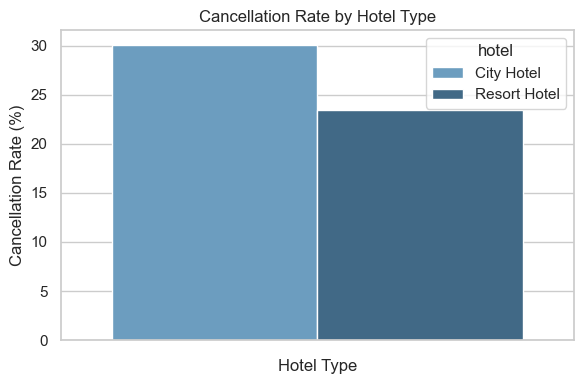

In [57]:
# Bar Plot
plt.figure(figsize = (6,4))
sns.barplot(hotel_cancel_df, hue = 'hotel', y = 'cancel_rate_percent', palette = 'Blues_d')

plt.title("Cancellation Rate by Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Hotel Type")
plt.tight_layout()
plt.show()

### Insight: Cancellation Rates by Hotel Type

To better communicate the difference in cancellation behavior, I visualized the cancellation rate for each hotel type.

The bar chart shows that the City Hotels have a higher cancellation rate (~30%) compared to Resort Hotel (~23%)

This suggests that customers booking City Hotels may be more likely to cancel — possibly due to more flexible booking terms, business travel uncertainty, or higher availability of alternatives in urban areas.

This observation could be useful in tailoring cancellation policies or predicting cancellations based on hotel type during modeling.

---


> ---
> ***Please Note: During an early inspection, I noticed some missing values in the `country` column. Since this variable isn't used in the current analysis steps, I've deferred handling it until the geographic analysis phase.***
>
> ---

---

## Cancellation Rates by Market Segment

After comparing hotel types, I wanted to dig deeper into customer behavior by analyzing market segments.

This variable shows the booking source, such as corporate booking, online travel agencies, or walk-ins. And I was also curious whether cancellation patterns differed across the channels.

To explore this, I grouped the dataset by `market_segment` and calculated the cancellation rate for each group

In [60]:
market_cancel_df = q("""
SELECT market_segment,
        COUNT(*) AS total_bookings,
        SUM(is_canceled) AS canceled_bookings,
        ROUND(AVG(is_canceled)*100,2) AS cancel_rate_percent
FROM df
GROUP BY market_segment
ORDER BY cancel_rate_percent DESC
""")

market_cancel_df

,market_segment,total_bookings,canceled_bookings,cancel_rate_percent
0,Undefined,2,2,100.00
1,Online TA,51618,18245,35.35
2,Groups,4942,1335,27.01
3,Aviation,227,45,19.82
4,Offline TA/TO,13889,2063,14.85
5,Direct,11804,1737,14.72
6,Complementary,702,88,12.54
7,Corporate,4212,510,12.11


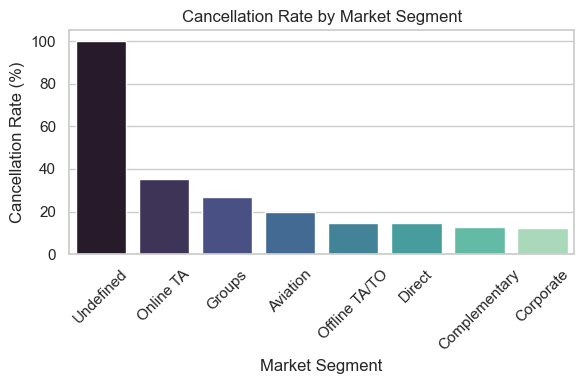

In [92]:
# Bar plot
plt.figure(figsize = (6, 4))
sns.barplot(market_cancel_df, x = 'market_segment',hue = 'market_segment', y = 'cancel_rate_percent',  palette = 'mako')

plt.title('Cancellation Rate by Market Segment')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Market Segment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight: Cancellation trend by Booking Segment:

This visualization highlights that bookings made through **Online TA (Travel Agencies)** show the highest cancellation rates (~35%), while **Corporate** and **Direct** bookings are more stable, with significantly lower cancellation rates. This likely reflect user behavior patterns common in online travel agency users. More exploratory bookings and price-sensitive decisions.

**Corporate** booking had the lowest cancellation rate at 12.11% reinforcing the idea that business travel tends to be more consistent and less prone to cancellation. 

I also noticed that some segments like `Undefined` had 100% cancellation.The 100% cancellation rate for the "Undefined" category is due to just 2 total bookings and can be considered noise. I'll likely exclude these low-frequency categories from downstream modeling to avoid skewing results.

---

## Cancellation Trends by Month

Next, I wanted to understand if there was any seasonal pattern in booking cancellation. Were certain months more prone to cancellation that others?

Since we had already created a numeric representation for `arrival_date_month` earlier, I grouped the data by this field and computed the cancellation rate per month. This would give me insight into when canellations peak throught the year.


In [ ]:
# Before proceeding, I need to convert the months into its abbreviation.
def abbreviate_month(month_name):
    return pd.to_datetime(month_name, format='%B').strftime('%b')

df['month_abbr'] = df['arrival_date_month'].apply(abbreviate_month)

In [ ]:
# SQL Query to get monthly cancellation rate

monthly_cancel_df = q("""
SELECT arrival_month_num,
    month_abbr,
    ROUND(AVG(is_canceled)*100,2) AS cancel_rate_percent
FROM df
GROUP BY arrival_month_num
ORDER BY arrival_month_num
""")
monthly_cancel_df

,arrival_month_num,month_abbr,cancel_rate_percent
0,1,Jan,22.12
1,2,Feb,23.20
2,3,Mar,24.36
3,4,Apr,30.46
4,5,May,29.23
5,6,Jun,30.32
6,7,Jul,31.80
7,8,Aug,32.18
8,9,Sep,24.54
9,10,Oct,23.68


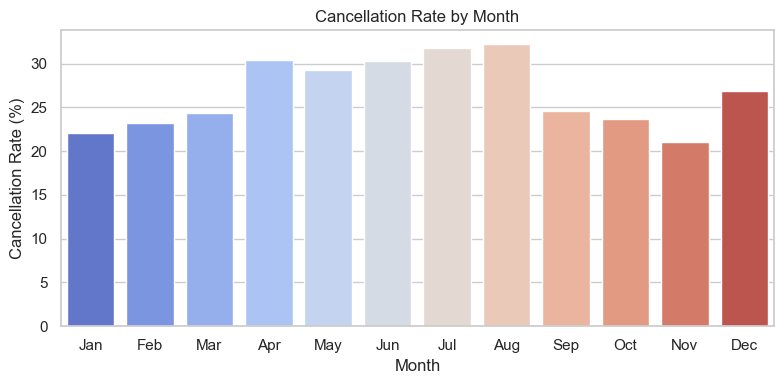

In [90]:
# Bar Plot
plt.figure(figsize = (8,4))
sns.barplot(monthly_cancel_df, x = 'month_abbr', y = 'cancel_rate_percent', hue = 'month_abbr', palette = 'coolwarm')
plt.title("Cancellation Rate by Month")
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

### Insight : Cancellation Trends by Month
Analyzing the cancellation rate across months revealed a clear seasonal trend. I noticed that **July and August** had the **highest cancellation rates**, both above 31%, which aligns with peak travel seasons in many regions. This could indicate that bookings made during vacation-heavy months are more prone to last-minute changes or overbooking.

In contrast, the **lowest cancellation rates** occurred in **November (21.6%)** and **January (22.1%)**, suggesting more stable booking patterns during off-peak months, possibly due to fewer travel uncertainties.

This trend helped me understand when hotels might experience more booking volatility. If I were advising hotel operations, I’d recommend taking these seasonal variations into account for staffing, overbooking strategies, and customer communication during peak-risk periods.

----

## Lead Time vs Cancellation Rate

Next, I wanted to explore whether the time gap between booking and arrival—also known as **lead time**, had any impact on cancellation behavior.

My hypothesis was that **longer lead times might correlate with higher cancellation rates**, since customers who book far in advance may be more likely to change plans compared to last-minute bookers.

To test this, I grouped the bookings into lead time bins and computed the cancellation rate within each range.


In [93]:
# Create lead time bins
lead_bins = [0, 7, 14, 30, 60, 90, 180, 365, df['lead_time'].max()]
lead_labels = ['0-7 days', '8-14 days', '15-30 days', '31-60 days', '61-90 days', '91-180 days', '181-365 days', '365+ days']
df['lead_time_group'] = pd.cut(df['lead_time'], bins=lead_bins, labels=lead_labels, right=False)

# Aggregate cancellation rates
lead_cancel_df = df.groupby('lead_time_group', observed=True).agg(
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum'),
    cancel_rate_percent=('is_canceled', lambda x: round(x.mean() * 100, 2))
).reset_index()

lead_cancel_df


,lead_time_group,total_bookings,canceled_bookings,cancel_rate_percent
0,0-7 days,17113,1391,8.13
1,8-14 days,6550,1250,19.08
2,15-30 days,10446,2880,27.57
3,31-60 days,13522,4252,31.45
4,61-90 days,9490,3126,32.94
5,91-180 days,18334,6390,34.85
6,181-365 days,11360,4500,39.61
7,365+ days,580,236,40.69


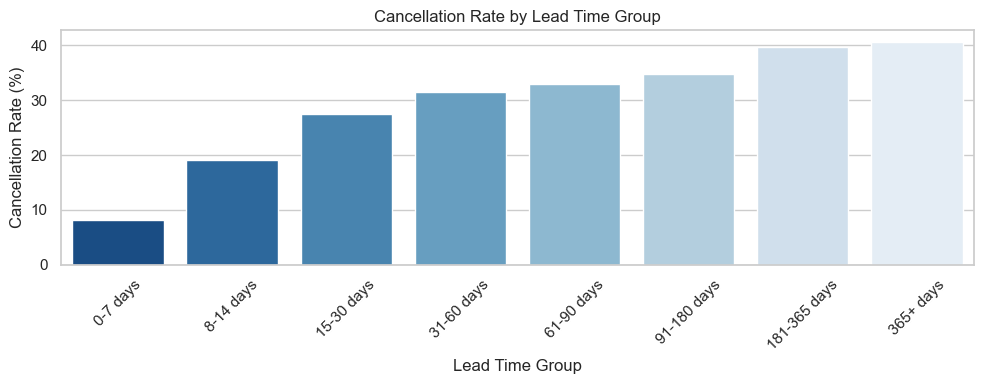

In [96]:
# Barplot
plt.figure(figsize=(10, 4))
sns.barplot(data=lead_cancel_df, x='lead_time_group', hue='lead_time_group', y='cancel_rate_percent', palette='Blues_r')
plt.title("Cancellation Rate by Lead Time Group")
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Lead Time Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Insight: Cancellation Rate by Lead Time

As I had initially suspected, there’s a clear trend: **the longer the lead time, the higher the cancellation rate**.

- Guests who booked **less than a week in advance** had a cancellation rate of just **8.1%**, which is the lowest among all groups.
- In contrast, those who booked **more than 6 months ahead (181–365 days)** had a cancellation rate close to **40%**.
- Interestingly, even bookings made a **year in advance (365+ days)** had a high cancellation rate, though the volume was small.

This suggests that **uncertainty increases with lead time**, and guests booking far in advance are more likely to cancel. This insight could be valuable for **revenue management** and setting **deposit policies** for longer-term bookings.

---

## Cancellation by Customer Type

To better understand customer behavior, I analyzed the cancellation rates across different customer types. These include:

- **Transient**: Individual travelers not associated with a group or contract
- **Contract**: Bookings under corporate or negotiated contracts
- **Group**: Large bookings from event organizers or agencies
- **Transient-Party**: A mix of individual and group bookings

My goal was to uncover whether certain segments are more likely to cancel, which could inform retention strategies.


In [99]:
customer_cancel_df = q("""
SELECT customer_type,
        COUNT(*) AS total_bookings,
        SUM(is_canceled) AS canceled_bookings,
        ROUND(AVG(is_canceled)*100,2) AS cancel_rate_percent
FROM df
GROUP BY customer_type    
ORDER BY cancel_rate_percent DESC
""")

customer_cancel_df

,customer_type,total_bookings,canceled_bookings,cancel_rate_percent
0,Transient,71986,21672,30.11
1,Contract,3139,512,16.31
2,Transient-Party,11727,1787,15.24
3,Group,544,54,9.93


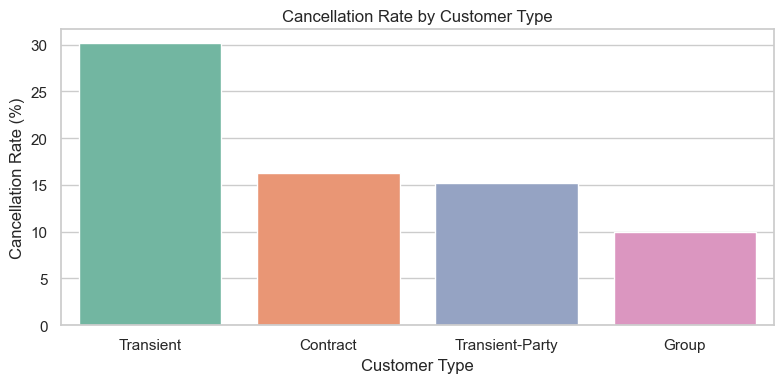

In [101]:
# Bar plot
plt.figure(figsize = (8,4))
sns.barplot(customer_cancel_df, x = 'customer_type', hue = 'customer_type', y = 'cancel_rate_percent', palette = 'Set2')
plt.title('Cancellation Rate by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Cancellation Rate (%)')
plt.tight_layout()
plt.show()

### Insight: Cancellation Rates by Customer Type

I found that **Transient customers** had the highest cancellation rate at **30.11%**, followed by **Contract** and **Transient-Party** customers. 

Surprisingly, **Group bookings** had the lowest cancellation rate of just **9.93%**, likely due to more structured or planned commitments.

This suggests that **individual travelers** are more likely to cancel than group or corporate bookings, reinforcing the importance of tailored retention strategies based on customer segments.

---

### Cancellation by Deposit Type

To explore how payment policies might affect customer commitment, I examined cancellation patterns based on the type of deposit required during booking.

This variable includes:
- **No Deposit**: No upfront payment required.
- **Non Refund**: Full payment made and non-refundable.
- **Refundable**: Payment required but refundable under certain conditions.

My goal was to see whether requiring a deposit impacts the likelihood of cancellations.


In [102]:
deposit_cancel_df = q("""
SELECT deposit_type,
       COUNT(*) AS total_bookings,
       SUM(is_canceled) AS canceled_bookings,
       ROUND(AVG(is_canceled)*100, 2) AS cancel_rate_percent
FROM df
GROUP BY deposit_type
ORDER BY cancel_rate_percent DESC
""")
deposit_cancel_df


,deposit_type,total_bookings,canceled_bookings,cancel_rate_percent
0,Non Refund,1038,983,94.70
1,No Deposit,86251,23016,26.68
2,Refundable,107,26,24.30


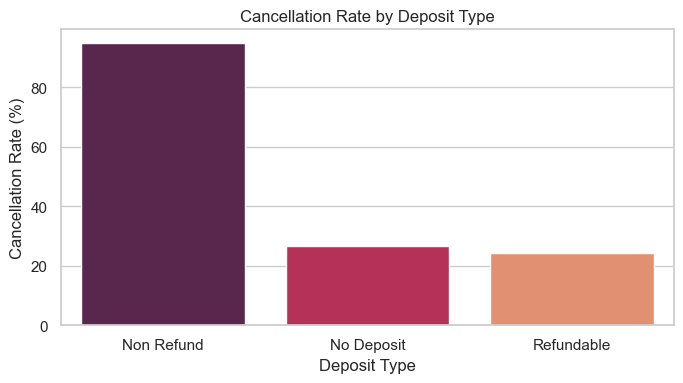

In [104]:
# Barplot – Cancellation Rate by Deposit Type
plt.figure(figsize=(7,4))
sns.barplot(data=deposit_cancel_df, x='deposit_type', hue = 'deposit_type', y='cancel_rate_percent', palette='rocket')
plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()


### Insight: Cancellation Rates by Deposit Type

After visualizing the cancellation rate by deposit type, I was surprised to find that bookings labeled as **Non Refund** had the **highest cancellation rate** at **94.7%**. This was unexpected, since non-refundable policies usually discourage cancellations.

I suspect this may be due to **urgent last-minute situations**, **accidental bookings**, or even **poor understanding of refund rules**. Customers may also perceive non-refundable rates as cheaper, only to cancel later if plans change.

In contrast, **Refundable** bookings showed the **lowest cancellation rate (24.3%)**, followed closely by **No Deposit bookings (26.7%)**. This trend indicates that customers who opt for more flexible terms are often **more intentional** with their reservations.

This insight could be useful for hotel managers in balancing their **pricing strategy** and **cancellation policies**, especially when designing promotions or targeting specific customer segments.

---

## Cancellation Trends by Room Type Mismatch

I wanted to test a hypothesis: **Are customers more likely to cancel when they're assigned a room different from what they originally reserved?**

Such mismatches could lead to dissatisfaction and cancellations—especially if the assigned room is perceived as a downgrade.

To explore this, I created a flag for mismatched room types and compared cancellation rates.


In [105]:
# Create a mismatch flag
df['room_mismatch'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

# Run SQL query to analyze cancellation rate by mismatch
room_cancel_df = q("""
    SELECT room_mismatch,
           COUNT(*) AS total_bookings,
           SUM(is_canceled) AS canceled_bookings,
           ROUND(AVG(is_canceled) * 100, 2) AS cancel_rate_percent
    FROM df
    GROUP BY room_mismatch
""")
room_cancel_df


,room_mismatch,total_bookings,canceled_bookings,cancel_rate_percent
0,0,74287,23408,31.51
1,1,13109,617,4.71


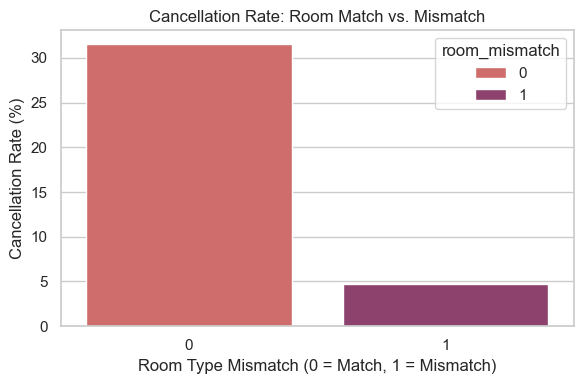

In [107]:
# Bar Plot
plt.figure(figsize=(6,4))
sns.barplot(data=room_cancel_df, x='room_mismatch', hue='room_mismatch', y='cancel_rate_percent', palette='flare')
plt.title("Cancellation Rate: Room Match vs. Mismatch")
plt.xlabel("Room Type Mismatch (0 = Match, 1 = Mismatch)")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()


### Insight: Room Type Mismatch vs Cancellation

Unexpectedly, **room type mismatches** (where the reserved room type differed from the assigned room) had a **much lower cancellation rate (~5%)** compared to bookings where room types matched (~31%).

This indicates that **room mismatch usually happens after booking**, and guests typically **accept the change rather than cancel**.

<div style='background-color: #f9f9f9; padding: 10px; border-left: 4px solid #ccc; font-size: 90%;'>
<b>💡 Key Takeaway:</b><br>
Room mismatches do not lead to higher cancellations. Guests generally accept room changes without canceling.
</div>

---
